<img src="../assets/imgs/MISIS_logoblock_main_inv_rus_RGB-01_4.svg" alt="НИТУ МИСИС - лого" width="300" height="200"/>

# Интеллектуальный анализ данных (ИАД)
## Влияние обеспеченности врачебными кадрами на ожидаемую продолжительность жизни в регионах РФ (2011 г.)

**Студент:** Сидоров Евгений Александрович  
**Группа:** МИСТ 25-2-2  
**Дата:** 26.05.2026

---

## Целевой источник - <img src="../assets/imgs/Russian_Federal_State_Statistics_Service_Emblem.png" alt="НИТУ МИСИС - лого" width="32" height="32"/> РОССТАТ

- Росстат Регионы России. Социально - экономические показатели - 2012г [https://rosstat.gov.ru/bgd/regl/B12_14p/Main.htm]
- Ожидаемая родолжительность жизни при рождении [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/03-13.htm]
- Численность врачей всех специальностей [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/07-06.htm]
- Численность населения [https://rosstat.gov.ru/bgd/regl/B12_14p/IssWWW.exe/Stg/d01/03-01.htm]

---

# ЧАСТЬ 1. Первичный анализ, регрессия и диагностика

## Постановка задачи исследования

### 1. Цель и задачи исследования

**Цель исследования:** Выявить статистическую зависимость между обеспеченностью врачебными кадрами и ожидаемой продолжительностью жизни в регионах РФ в 2011 году для обоснования приоритетов регионального здравоохранения.

**Задачи исследования:**
1. Провести первичный анализ и очистку данных по 83 регионам РФ (согласно данным Росстат за 2011г.);
2. Рассчитать описательные статистики и оценить вариативность показателей;
3. Сформулировать и проверить гипотезу о значимости влияния обеспеченности врачами на ОПЖ (Ожидаемая Продолжительность Жизни при рождении, в контексте задачи - для всего населения без привязки к полу);
4. Построить модель простой линейной регрессии и оценить её адекватность;

<font color="gray">

5. Провести кластеризацию регионов;
6. Построить уточнённые регрессионные модели внутри выделенных кластеров.

</font>

### 2. Проверяемая гипотеза

Т.к. в качестве независимой переменной X выступает обеспеченность врачами (по регионам РФ), а зависимой переменной Y выступает ожидаемая продолжительность жизни при рождении, то простая линейная регрессионая модель имет вид:

\begin{aligned}
    y_i = \beta_0 + \beta_1 \times x_i + \varepsilon_i
\end{aligned}

где:
- $x_i$  — Свободный член, численность врачей
- $y_i$ — Зависимый ОПЖ
- $\beta_0$ — свободный член (ожидаемая ОПЖ при нулевой обеспеченности врачами)
- $\beta_1$ — коэффициент: изменение ОПЖ при росте обеспеченности врачами на 1 чел. на 10 тыс. населения
- $\varepsilon_i$ — случайная ошибка

В соответсвии с предполагаемой моделью выдвигается гипотеза:

$$
\begin{aligned}
H_0:&\ \beta_1 = 0 && \text{— обеспеченность врачами не влияет на ОПЖ} \\
H_1:&\ \beta_1 \neq 0 && \text{— существует значимая связь между обеспеченностью врачами и ОПЖ}
\end{aligned}
$$

**Уровень значимости:** $\alpha = 0.05$

### 3. Актуальность исследования

Ожидаемая продолжительность жизни является одним из ключевых индикаторов качества жизни и эффективности системы здравоохранения (ВОЗ). В условиях регионального неравенства в РФ выявление факторов, влияющих на демографические показатели, имеет высокую практическую значимость.

Ряд исследований подтверждает положительную корреляцию между доступностью медицинской помощи и показателями здоровья населения.

Шабанова и Соболева (2018) продемонстрировали, что медицинские факторы определяют лишь 10–20% вариации ОПЖ, уступая по значимости образу жизни, экологическим условиям и уровню доходов.

Данное исследование направлено на количественную оценку вклада обеспеченности врачами в вариацию ОПЖ по регионам РФ, что может служить основанием для обоснования распределения ресурсов в рамках государственных программ развития здравоохранения.

### 4. План-схема выполнения исследования

```mermaid
graph TD
    A[Загрузка данных] --> B[Предобработка и валидация]
    B --> C[Описательная статистика]
    C --> D[Графический анализ]
    D --> E[Корреляционный анализ]
    E --> F[Регрессионная модель]
    F --> G[Проверка гипотез]
    G --> H[Кластеризация]
    H --> I[Уточнённые модели по кластерам]
    I --> J[Итоговые выводы]
```

## Импорт библиотек и настройка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
import warnings
import os

# Настройки отображения и графиков
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Создание папки для сохранения графиков
os.makedirs('figures', exist_ok=True)

print("Библиотеки импортированы, настройки применены")

Библиотеки импортированы, настройки применены


## Загрузка и подготовка данных

In [9]:
columns = [
    'federal_district', 
    'region', 
    'population_k', 
    'number_of_doctors_k',
    'life_expectancy_all',
    'life_expectancy_male',
    'life_expectancy_female'
]

numeric_columns = [
    'population_k',
    'number_of_doctors_k',
    'life_expectancy_all',
    'life_expectancy_male',
    'life_expectancy_female'
]

stroke_columns = [
    'federal_district',
    'region'
]

schema = {
    'federal_district': str,
    'region': str,
    'population_k': float,
    'number_of_doctors_k': float,
    'life_expectancy_all': float,
    'life_expectancy_male': float,
    'life_expectancy_female': float,
}


# Загрузка данных (разделитель ';', кодировка 'utf-8')
df = pd.read_csv(
    '../data/encodedUTF8_сombining_samples_for_2011.csv', 
    sep = ';', 
    encoding = 'utf-8',
    names = columns,
    header = 0,
    dtype = schema
    )

print(f'Исходный размер: {df.shape[0]} строк')

# ❗ УДАЛЕНИЕ объединённых записей 1990 года — не субъекты РФ в 2011 г.
remove_regions = [
    'Республика Ингушетия (1990 г. - включая Чеченскую Республику)',
    'Чеченская Республика (1990 г. - включая Республику Ингушетия)'
]
df = df[~df['region'].isin(remove_regions)].copy().reset_index(drop=True)
print(f'После удаления: {df.shape[0]} строк (субъекты РФ по состоянию на 2011 г.)')
print("Первые 5 строк датасета:")
display(df.head())
print(f"\nРазмер итогового датасета: {df.shape[0]} строк на {df.shape[1]} столбцов")
print(f"\nНазвания столбцов:\n{df.columns.tolist()}")

Исходный размер: 83 строк
После удаления: 81 строк (субъекты РФ по состоянию на 2011 г.)
Первые 5 строк датасета:


,federal_district,region,population_k,number_of_doctors_k,life_expectancy_all,life_expectancy_male,life_expectancy_female
0,Центральный федеральный округ,Белгородская область,1536.0,6.2,71.71,66.22,77.11
1,Центральный федеральный округ,Брянская область,1264.0,4.6,68.83,62.28,75.71
2,Центральный федеральный округ,Владимирская область,1432.0,5.0,68.08,61.77,74.42
3,Центральный федеральный округ,Воронежская область,2332.0,12.6,70.41,64.45,76.44
4,Центральный федеральный округ,Ивановская область,1054.0,5.7,68.56,62.19,74.79



Размер датасета: 81 строк на 7 столбцов

Названия столбцов:
['federal_district', 'region', 'population_k', 'number_of_doctors_k', 'life_expectancy_all', 'life_expectancy_male', 'life_expectancy_female']


## Валидация и предобработка данных

### 5. Проверка на пропуски и невалидные значения

Также в данном пункте выполнен расчет нормалитзованного показателя: врачи на 10 000 населения.

In [13]:
print("Пропущенные значения по столбцам:")
print(df.isnull().sum())

# Проверка на отрицательные значения в числовых колонках

print(f"\nПроверка на отрицательные значения в ключевых переменных:")
for col in numeric_columns:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} отрицательных значений")
print()
    
# Нормализация:
# Расчёт нормализованного показателя обеспеченности врачами (масштатибрование по численности населения в регионе)
# Т.к. прямое сопоставление численности врачей по разным регионам 
# не даст хороших показателей из-за колоссального разброса по численности жителей в областях
# Вводим новую переменную:
# Формула: doctors_per_10k = (врачи_тыс / население_тыс) × 10 000
df['doctors_per_10k'] = (df['number_of_doctors_k'] / df['population_k']) * 10000

# Переименуем целевую переменную для удобства
# Т.к. мы не рассматриваем ОПЖ для мужчин и женщин в отдеьности, а проводим анализ по всему населению
df['life_exp'] = df['life_expectancy_all']

print("Созданы новые колонки для переменных:")
print("- doctors_per_10k — обеспеченность врачами, чел. на 10 000 населения")
print("- life_exp — ожидаемая продолжительность жизни, лет")
print(f"\nДиапазон doctors_per_10k: [{df['doctors_per_10k'].min():.2f}; {df['doctors_per_10k'].max():.2f}]")
print(f"Диапазон life_exp: [{df['life_exp'].min():.2f}; {df['life_exp'].max():.2f}]")

# Проверка диапазона ОПЖ (логичный диапазон: 40-90 лет) 
# исключительно для первичной оценки и наглядности
life_exp_col = 'life_expectancy_all'
outliers_life = df[(df[life_exp_col] < 40) | (df[life_exp_col] > 90)]

# Дополнительные переменные для модификации
df['doctors_per_10k_sq'] = df['doctors_per_10k'] ** 2
df['log_doctors'] = np.log(df['doctors_per_10k'])
df['log_population'] = np.log(df['population_k'])

print(f"\nРегионы с ОПЖ вне диапазона [40; 90]: {len(outliers_life)}")
if len(outliers_life) > 0:
    display(outliers_life[['Область', life_exp_col]])
print(f'Диапазон doctors_per_10k: [{df.doctors_per_10k.min():.2f}; {df.doctors_per_10k.max():.2f}]')
print(f'Диапазон life_exp: [{df.life_exp.min():.2f}; {df.life_exp.max():.2f}]')

Пропущенные значения по столбцам:
federal_district          0
region                    0
population_k              0
number_of_doctors_k       0
life_expectancy_all       0
life_expectancy_male      0
life_expectancy_female    0
doctors_per_10k           0
life_exp                  0
doctors_per_10k_sq        0
log_doctors               0
log_population            0
dtype: int64

Проверка на отрицательные значения в ключевых переменных:
population_k: 0 отрицательных значений
number_of_doctors_k: 0 отрицательных значений
life_expectancy_all: 0 отрицательных значений
life_expectancy_male: 0 отрицательных значений
life_expectancy_female: 0 отрицательных значений

Созданы новые колонки для переменных:
- doctors_per_10k — обеспеченность врачами, чел. на 10 000 населения
- life_exp — ожидаемая продолжительность жизни, лет

Диапазон doctors_per_10k: [30.13; 87.22]
Диапазон life_exp: [61.39; 75.79]

Регионы с ОПЖ вне диапазона [40; 90]: 0
Диапазон doctors_per_10k: [30.13; 87.22]
Диапазон life

## Описательная статистика

### 6.1. Основные статистические показатели

In [20]:
# Описательная статистика для ключевых переменных
target_vars = ['life_exp', 'doctors_per_10k']
# Описываем персиентили (квартили) Q1, Q2, Q3 - нижние 25%, медиана 50% и верхние 75%
desc_stats = df[target_vars].describe(percentiles=[0.25, 0.5, 0.75])

# Добавим коэффициент вариации и IQR (межквартильный размах [Q3 - Q1])
desc_stats.loc['CV, %'] = desc_stats.loc['std'] / desc_stats.loc['mean'] * 100
desc_stats.loc['IQR'] = desc_stats.loc['75%'] - desc_stats.loc['25%']

print("Описательная статистика ключевых переменных:")
display(desc_stats.round(3))

# Сохранение в таблицу для отчёта
desc_stats.round(3).to_csv('figures/descriptive_stats.csv', encoding='utf-8')
print("\nТаблица сохранена: figures/descriptive_stats.csv")

Описательная статистика ключевых переменных:


,life_exp,doctors_per_10k
count,81.000,81.000
mean,68.834,49.329
std,2.421,11.542
min,61.390,30.134
25%,67.750,40.668
50%,69.020,48.917
75%,70.160,56.381
max,75.790,87.220
"CV, %",3.518,23.397
IQR,2.410,15.713



Таблица сохранена: figures/descriptive_stats.csv


### 6.2. Формулы расчёта

$$
\begin{aligned}
&\text{Коэффициент вариации:} & CV = \frac{\sigma}{\mu} \times 100\% \\&\text{Межквартильный размах:} & IQR = Q_3 - Q_1 \\&\text{Границы выбросов:} & \text{Нижняя} = Q_1 - 1.5 \times IQR \\& & \text{Верхняя} = Q_3 + 1.5 \times IQR
\end{aligned}
$$

**Интерпретация CV:**
- $CV < 10\%$ — слабая вариация
- $10\% \le CV < 25\%$ — умеренная вариация
- $CV \ge 25\%$ — высокая вариация

> Определение:
>
> *IQR — это абсолютная мера разброса (в тех же единицах, что и данные). Зачем нужен: Помогает понять, где сосредоточена "середина" данных, не чувствителен к экстремальным выбросам. Применение: Используется для поиска выбросов (все, что меньше Q1 - 1.5IQR или больше Q3 + 1.5IQR)
>
> *CV — это относительная мера разброса (безразмерная величина). Зачем нужен: Позволяет сравнивать вариативность данных, измеренных в разных шкалах или имеющих разные средние значения (например, вес в кг и рост в см).Интерпретация: Чем ниже CV, тем выше однородность данных. 

### 6.3. Краткие выводы по описательной статистике


In [19]:
# Автоматическая генерация выводов на основе статистик
cv_life = desc_stats.loc['CV, %', 'life_exp']
cv_docs = desc_stats.loc['CV, %', 'doctors_per_10k']

def interpret_cv(cv):
    if cv < 10:
        return "слабая"
    elif cv < 25:
        return "умеренная"
    else:
        return "высокая"

print(f"Выводы по описательной статистике:")
print(f"- Средняя ОПЖ по регионам: {desc_stats.loc['mean', 'life_exp']:.2f} лет")
print(f"- Коэффициент вариации (CV) ОПЖ: {cv_life:.2f}% - {interpret_cv(cv_life)} вариативность между регионами")
print(f"- Межквартильный размах (IQR) ОПЖ: {desc_stats.loc['IQR', 'life_exp']:.2f} лет (центральные 50% регионов)")
print('')
print(f"- Средняя обеспеченность врачами: {desc_stats.loc['mean', 'doctors_per_10k']:.2f} чел. на 10 тыс. населения")
print(f"- Коэффициент вариации (CV) обеспеченности врачами: {cv_docs:.2f}% - {interpret_cv(cv_docs)} вариативность")
print(f"- Межквартильный размах (IQR): {desc_stats.loc['IQR', 'doctors_per_10k']:.2f} чел. на 10 тыс. населения")

Выводы по описательной статистике:
- Средняя ОПЖ по регионам: 68.83 лет
- Коэффициент вариации (CV) ОПЖ: 3.52% - слабая вариативность между регионами
- Межквартильный размах (IQR) ОПЖ: 2.41 лет (центральные 50% регионов)

- Средняя обеспеченность врачами: 49.33 чел. на 10 тыс. населения
- Коэффициент вариации (CV) обеспеченности врачами: 23.40% - умеренная вариативность
- Межквартильный размах (IQR): 15.71 чел. на 10 тыс. населения


## Графический анализ распределения и выбросов

### 7.1. Гистограммы

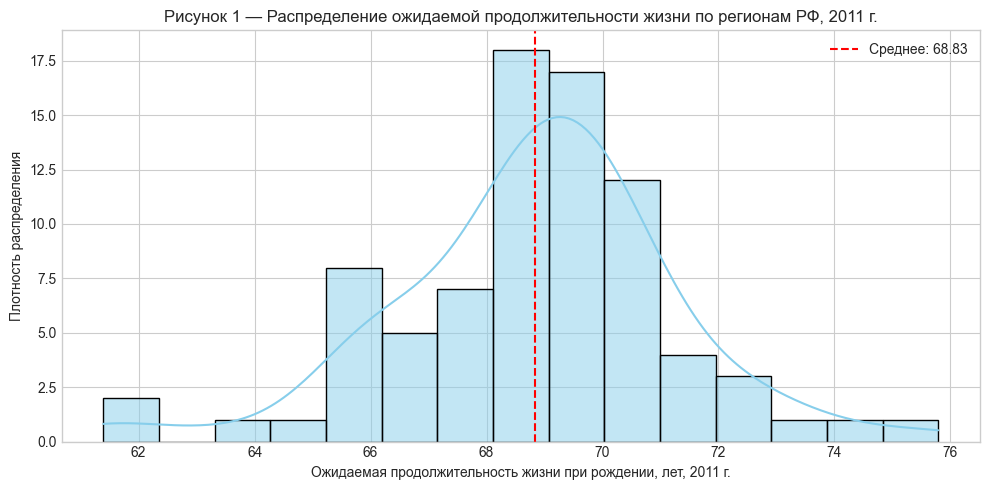

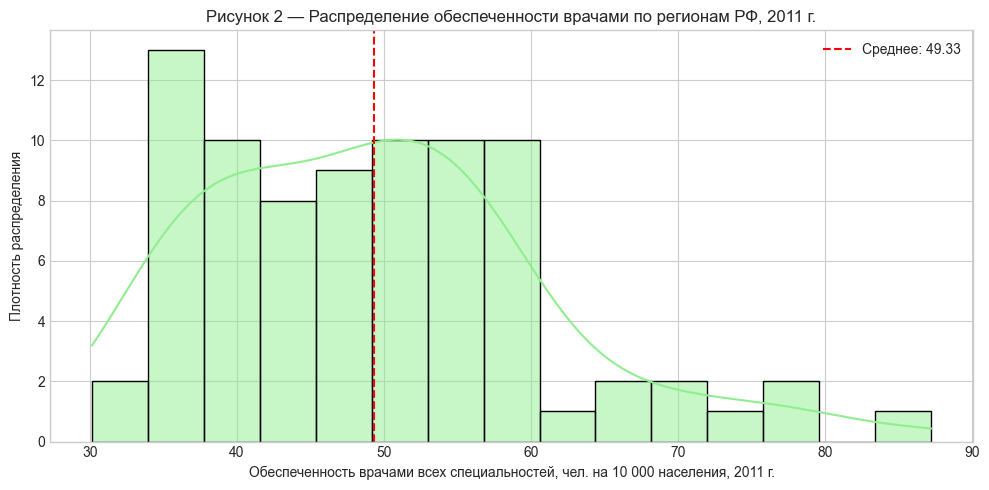

In [23]:
# Гистограмма ОПЖ
plt.figure(figsize=(10, 5))
sns.histplot(df['life_exp'], bins=15, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Ожидаемая продолжительность жизни при рождении, лет, 2011 г.')
plt.ylabel('Плотность распределения')
plt.title('Рисунок 1 — Распределение ожидаемой продолжительности жизни по регионам РФ, 2011 г.')
plt.axvline(df['life_exp'].mean(), color='red', linestyle='--', label=f'Среднее: {df["life_exp"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('figures/hist_life_exp.png', dpi=300)
plt.show()

# Гистограмма обеспеченности врачами
plt.figure(figsize=(10, 5))
sns.histplot(df['doctors_per_10k'], bins=15, kde=True, color='lightgreen', edgecolor='black')
plt.xlabel('Обеспеченность врачами всех специальностей, чел. на 10 000 населения, 2011 г.')
plt.ylabel('Плотность распределения')
plt.title('Рисунок 2 — Распределение обеспеченности врачами по регионам РФ, 2011 г.')
plt.axvline(df['doctors_per_10k'].mean(), color='red', linestyle='--', label=f'Среднее: {df["doctors_per_10k"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('figures/hist_doctors.png', dpi=300)
plt.show()

### 7.2. Boxplot

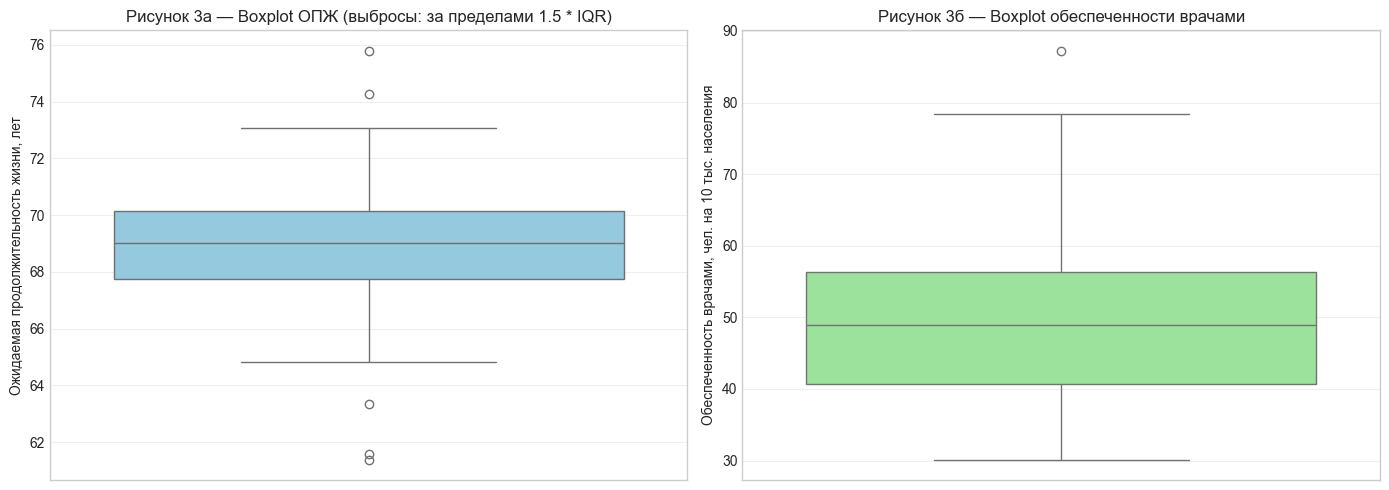


Выбросы в life_exp (метод 1.5 * IQR):


,region,life_exp
62,Республика Тыва,61.39
80,Чукотский автономный округ,61.58
79,Еврейская автономная область,63.35
35,Республика Дагестан,74.26
17,г. Москва,75.79



Выбросы в doctors_per_10k (метод 1.5 * IQR):


,region,doctors_per_10k
28,г. Санкт-Петербург,87.22


In [24]:
# Boxplot для ОПЖ и обеспеченности врачами
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ОПЖ
sns.boxplot(y=df['life_exp'], ax=axes[0], color='skyblue')
axes[0].set_ylabel('Ожидаемая продолжительность жизни, лет')
axes[0].set_title('Рисунок 3а — Boxplot ОПЖ (выбросы: за пределами 1.5 * IQR)')
axes[0].grid(axis='y', alpha=0.3)

# Врачи
sns.boxplot(y=df['doctors_per_10k'], ax=axes[1], color='lightgreen')
axes[1].set_ylabel('Обеспеченность врачами, чел. на 10 тыс. населения')
axes[1].set_title('Рисунок 3б — Boxplot обеспеченности врачами')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/boxplots.png', dpi=300)
plt.show()

# Вывод выбросов для анализа
def find_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(series < lower) | (series > upper)]
    print(f"\nВыбросы в {name} (метод 1.5 * IQR):")
    if len(outliers) > 0:
        display(outliers[['region', name]].sort_values(name))
    else:
        print("Нет выбросов")
    return outliers

outliers_life = find_outliers_iqr(df['life_exp'], 'life_exp')
outliers_docs = find_outliers_iqr(df['doctors_per_10k'], 'doctors_per_10k')

### 7.3. Диаграмма рассеяния

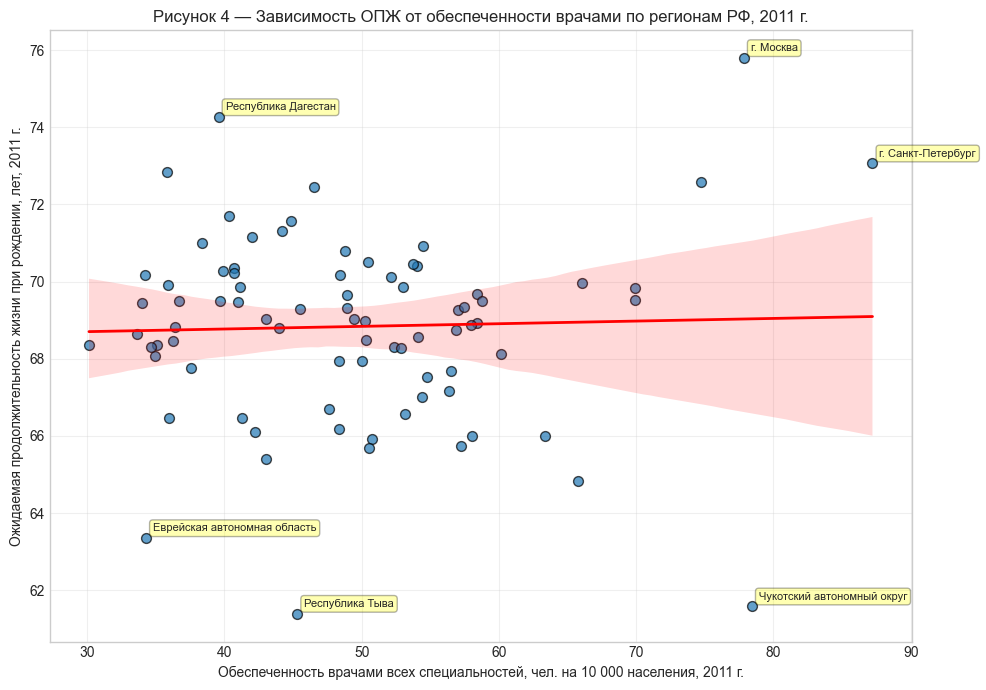

In [25]:
# Scatter plot с линией регрессии и аннотациями ключевых регионов
plt.figure(figsize=(10, 7))
sns.regplot(x='doctors_per_10k', y='life_exp', data=df, 
            scatter_kws={'alpha':0.7, 's':50, 'edgecolor':'black'}, 
            line_kws={'color':'red', 'linewidth':2})

# Подпись ключевых регионов (Москва, Тыва, Чукотка и т.п. на основе анализа предыдущей ячейки)
key_regions =[*outliers_life['region'], *outliers_docs['region']]

for _, row in df[df['region'].isin(key_regions)].iterrows():
    plt.annotate(row['region'], 
                (row['doctors_per_10k'], row['life_exp']),
                textcoords="offset points", 
                xytext=(5,5), 
                ha='left',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel('Обеспеченность врачами всех специальностей, чел. на 10 000 населения, 2011 г.')
plt.ylabel('Ожидаемая продолжительность жизни при рождении, лет, 2011 г.')
plt.title('Рисунок 4 — Зависимость ОПЖ от обеспеченности врачами по регионам РФ, 2011 г.')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/scatter_regression.png', dpi=300)
plt.show()

### 7.4. Выводы по выбросам

Диаграмма рассеяния показывает аномалии в сочетании двух признаков и их отклонение от общего тренда (красной линии):
1. Республика Дагестан: Аномально высокая продолжительность жизни при относительно низкой обеспеченности врачами;
2. Чукотский АО: Аномально низкая продолжительность жизни при крайне высокой обеспеченности врачами. Это говорит о сильном влиянии других факторов (климат, условия жизни);/
3. г. Москва и г. Санкт-Петербург: Лидеры по обоим показателям, сильно оторванные от основного кластера регионов.
4. В свою очередь Еврейская автономная область и Республика тыва наоборот, показывают ожидаемую, "мнимую" корреляцию (мало врачей - меньше ОПЖ), однако их показатели ОПЖ, в отличие от Республики Дагестан и других в скоплении являются сильно заниженными, вероятно это также связано с климатическими условиями, особенностями местности или социально-экономическими особенностями региона.


| Регион | Тип выброса на графике | Главные причины аномалии (состояние на 2011–2012 гг.) | Источники информации |
| :--- | :--- | :--- | :--- |
| **Республика Тыва** | Крайне низкая ОПЖ (~61.4 года) при средней обеспеченности врачами (~45 чел.) | Высокий уровень бедности и безработицы; критические показатели смертности трудоспособного населения от внешних причин (алкоголизация, бытовое насилие, ДТП, несчастные случаи); географическая изоляция и логистическая труднодоступность отдаленных районов. | [Доклад Минздрава Республики Тыва](https://www.minzdravtuva.ru/3-11-22-%D0%BA%D0%BE%D0%BB%D0%BB%D0%B5%D0%B3%D0%B8%D1%8F.html)<br>[Анализ КиберЛенинка](https://cyberleninka.ru) |
| **Еврейская АО (ЕАО)** | Низкая ОПЖ (~63.4 года) и критически низкое число врачей (~33 чел.) | Хронический дефицит медицинских кадров из-за миграционного оттока специалистов; высокая младенческая смертность (почти вдвое выше средней по РФ); выраженная маргинализация и высокая смертность мужчин трудоспособного возраста от болезней системы кровообращения и алкогольных отравлений. | [Постановление Правительства ЕАО](https://docs.cntd.ru/document/441650225)<br>[Демографический атлас регионов РФ](http://www.ecoross.ru/files/atlas/evr.shtml) |
| **Чукотский АО** | Аномально низкая ОПЖ (~61.6 года) при крайне высокой обеспеченности врачами (~78 чел.) | Экстремальный суровый климат Севера; специфика расселения коренных малочисленных народов с высокой уязвимостью к хроническим заболеваниям; суициды и несчастные случаи. Сверхвысокая доля врачей вызвана необходимостью содержать медицинские пункты в крошечных, изолированных и удаленных друг от друга поселках. | [Роспотребнадзор ЧАО](https://87rospotreb.ru/index.php/rospotrebnadzor/istoriya)<br>[Официальный сайт Чукотского АО](https://xn--80atapud1a.xn--p1ai/press-tsentr/novosti/?ELEMENT_ID=19225) |
| **Республика Дагестан** | Аномально высокая ОПЖ (~74.3 года) при умеренной обеспеченности врачами (~40 чел.) | Традиционно здоровый образ жизни (низкий уровень употребления алкоголя и курения); крепкие институты семьи и поддержка пожилых людей; благоприятные климатические факторы. *Экспертная оговорка:* Демографы также отмечают статистические искажения (переучет населения на бумаге после переписи 2010 года, занижающий реальные коэффициенты смертности). | [Статья "Кавказ.Реалии" / Выводы ВШЭ](https://www.kavkazr.com/a/dolgoletie-na-bumage/28595211.html)<br>[Исследование долголетия в Дагестане](https://cyberleninka.ru/article/n/nekotorye-dannye-o-dolgoletii-v-dagestanskoy-assr) |
| **г. Москва** | Сверхвысокие показатели по обоим критериям (ОПЖ ~76 лет, врачи ~78 чел.) | Статус федерального центра; максимальная концентрация ведущих НИИ, крупных клиник и высокотехнологичной медицины. Дополнительные факторы: высокий уровень доходов населения, доступность ранней диагностики и лучшая в стране городская инфраструктура. | [Статистика Росстата по Москве](https://tsargrad.tv) |
| **г. Санкт-Петербург** | Сверхвысокая обеспеченность врачами (~87 чел.) при высокой ОПЖ (~73 года) | Вторая столица, один из главных медицинских, научных и образовательных хабов страны. Огромный массив федеральных клиник и медицинских вузов создает избыточную плотность кадров на душу населения по сравнению с другими регионами РФ. | [Обзор регионального здравоохранения](https://tsargrad.tv) |


## Корреляционный анализ

### 8.1. Коэффициент корреляции Пирсона

In [29]:
# Расчёт корреляции Пирсона и проверка значимости
r, p_value = stats.pearsonr(df['doctors_per_10k'], df['life_exp'])
n = len(df)
df_corr = n - 2  # степени свободы

# t-статистика для проверки значимости корреляции
t_calc_corr = r * np.sqrt(df_corr) / np.sqrt(1 - r**2)
t_crit_corr = stats.t.ppf(0.975, df_corr)  # двусторонний тест, α=0.05 (1-α/2 <=> 1 - 0,025 = 0.975)

print("Корреляционный анализ:")
print(f"\nКоэффициент Пирсона: r = {r:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"\nПроверка значимости:")
print(f"- t_расч = {t_calc_corr:.3f}")
print(f"- t_крит({df_corr}) = {t_crit_corr:.3f}")
print(f"- Решение: {'Отвергаем H₀' if abs(t_calc_corr) > t_crit_corr else 'Не отвергаем H₀'}")

# Интерпретация силы связи
abs_r = abs(r)
if abs_r < 0.3:
    strength = "слабая"
elif abs_r < 0.7:
    strength = "умеренная"
else:
    strength = "сильная"
direction = "положительная" if r > 0 else "отрицательная"

print(f"\nИнтерпретация: {strength} {direction} связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)")

Корреляционный анализ:

Коэффициент Пирсона: r = 0.0327
p-value: 0.7722

Проверка значимости:
- t_расч = 0.290
- t_крит(79) = 1.990
- Решение: Не отвергаем H₀

Интерпретация: слабая положительная связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)


### 8.2. Матрица корреляций

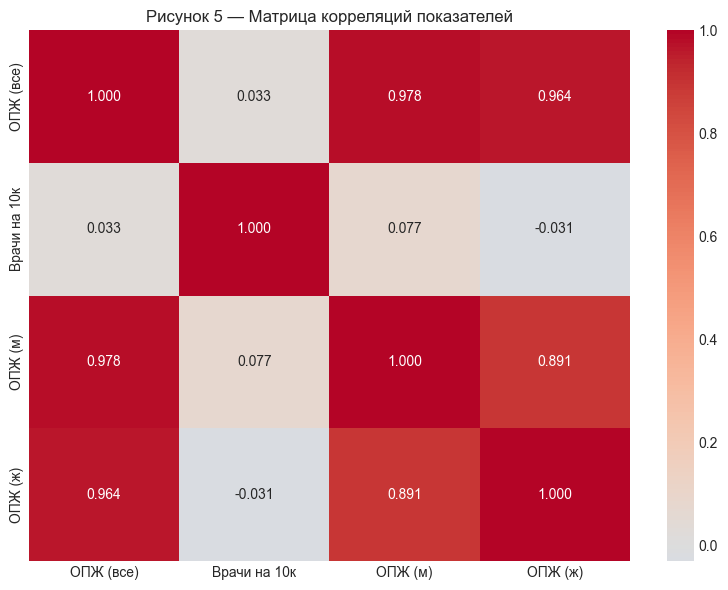

In [30]:
# Матрица корреляций для всех числовых переменных 
# Включены ОПЖ для мужчин и женщин только в демонстарционных целях
corr_cols = ['life_exp', 'doctors_per_10k', 
             'life_expectancy_male',
             'life_expectancy_female']

plt.figure(figsize=(8, 6))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=['ОПЖ (все)', 'Врачи на 10к', 'ОПЖ (м)', 'ОПЖ (ж)'],
            yticklabels=['ОПЖ (все)', 'Врачи на 10к', 'ОПЖ (м)', 'ОПЖ (ж)'])
plt.title('Рисунок 5 — Матрица корреляций показателей')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=300)
plt.show()

### 9. Вывод по предположениям (гипотезам), сформулированным в начале.

#### Статистический вывод по гипотезам

__Коэффициент корреляции:__ Значение коэффициента Пирсона между обеспеченностью врачами ("Врачи на 10к") и общей ожидаемой продолжительностью жизни ("ОПЖ (все)") составляет всего (0.033).

__Интерпретация:__ Коэффициент корреляции практически равен нулю $(r \approx 0)$. Это свидетельствует о крайне слабой, практически отсутствующей линейной взаимосвязи между данными показателями на уровне регионов.
Для отдельных полов: Ситуация аналогична как для мужчин (r = 0.077), так и для женщин, где корреляция и вовсе составляет (r = -0.031).


#### Итоговое решение


Нулевая гипотеза $(H_{0})$ принимается. У нас нет статистических оснований её отвергнуть.Линейный коэффициент наклона $(\beta _{1})$ в регрессионной модели будет статистически незначим и неотличим от нуля. Обеспеченность врачами (всех специальностей на 10 000 населения) сама по себе не имеет линейного влияния на ожидаемую продолжительность жизни в масштабах регионов РФ.


## Построение регрессионной модели

### 10. Спецификация модели

$$
\text{ОПЖ}_i = \beta_0 + \beta_1 \times \text{Врачи\_на\_10к}_i + \varepsilon_i
$$

где:
- $\beta_0$ — свободный член (ожидаемая ОПЖ при нулевой обеспеченности врачами)
- $\beta_1$ — коэффициент: изменение ОПЖ при росте обеспеченности врачами на 1 чел. на 10 тыс. населения
- $\varepsilon_i$ — случайная ошибка

In [34]:
# Подготовка данных для регрессии (удаляем пропуски)
df_reg = df.dropna(subset=['life_exp', 'doctors_per_10k']).copy()

# X и Y
X = sm.add_constant(df_reg['doctors_per_10k'])  # добавляем константу β₀
Y = df_reg['life_exp']

# Оценка модели МНК
model = sm.OLS(Y, X).fit()

# Вывод подробной сводки модели
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                   0.08438
Date:                Tue, 26 May 2026   Prob (F-statistic):              0.772
Time:                        21:39:12   Log-Likelihood:                -186.02
No. Observations:                  81   AIC:                             376.0
Df Residuals:                      79   BIC:                             380.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              68.4960      1.195     

### 11.1 Проверка гипотезы о значимости β₁

$$
\begin{aligned}
&\text{Проверяемая гипотеза:} \\
&H_0: \beta_1 = 0 \quad \text{(врачи не влияют на ОПЖ)} \\
&H_1: \beta_1 \neq 0 \quad \text{(влияние есть)} \\
\\ 
&\text{Расчёт t-статистики:} \\
&t_{\text{расч}} = \frac{\hat{\beta}_1}{SE(\hat{\beta}_1)} = \frac{[\text{значение } \beta_1]}{[\text{значение SE}]} = [\text{рассчитанное}] \\
\\ 
&\text{Степени свободы:} \quad df = n - 2 = [n] - 2 = [df] \\
\\ 
&\text{Критическое значение } (\alpha = 0.05, \text{двусторонний} \implies \alpha_\text{1/2} = 0.025): \\
&t_{\text{крит}} = t_{0.975; [df]} \approx [\text{значение}] \\
\\ 
&\text{p-value} = [\text{значение из вывода модели}] \\
\\ 
&\text{Решение:} \\
&\text{Если } |t_{\text{расч}}| > t_{\text{крит}} \text{ ИЛИ } p\text{-value} < 0.05 \rightarrow \text{отвергаем } H_0 \\
\end{aligned}
$$

### 11.2. Оценка адекватности модели

In [35]:
print(f'R² = {model.rsquared:.4f} ({model.rsquared*100:.2f}% вариации)')
print(f'Adj. R² = {model.rsquared_adj:.4f}')
print(f'F = {model.fvalue:.4f}, p(F) = {model.f_pvalue:.4f}')
print(f'Модель: {"адекватна" if model.f_pvalue < 0.05 else "НЕ адекватна"}')

# Тесты
residuals = model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f'Шапиро-Уилка: W={shapiro_stat:.4f}, p={shapiro_p:.4f}')
print(f'Дарбин-Уотсон: {sm.stats.durbin_watson(residuals):.4f}')

R² = 0.0011 (0.11% вариации)
Adj. R² = -0.0116
F = 0.0844, p(F) = 0.7722
Модель: НЕ адекватна
Шапиро-Уилка: W=0.9634, p=0.0207
Дарбин-Уотсон: 0.8207


### 11.3. Графики диагностики

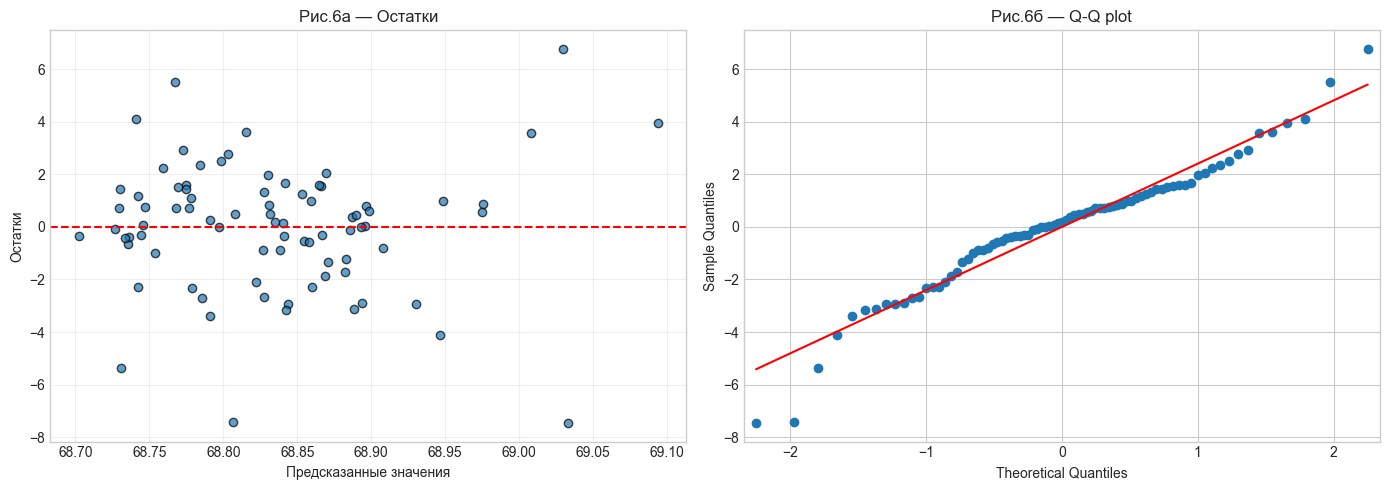

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(model.fittedvalues, residuals, alpha=0.7, edgecolors='black')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Остатки')
axes[0].set_title('Рис.6а — Остатки')
axes[0].grid(alpha=0.3)
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Рис.6б — Q-Q plot')
plt.tight_layout()
plt.savefig('figures/regression_diagnostics.png', dpi=300)
plt.show()

На основе предоставленных метрик и графиков диагностики можно сделать однозначный вывод: 
Построенная парная линейная регрессионная модель неадекватна. Ниже приведен подробный анализ по ключевым критериям:
1. Качество аппроксимации и объясняющая сила $(R^{2})$
2. Коэффициент детерминации $(R^2 = 0.0011)$. Модель объясняет всего 0.11% дисперсии зависимой переменной (ОПЖ). Остальные 99.89% вариации обусловлены факторами, не включенными в модель.
3. Скорректированный $(Adj.\ R^2 = -0.0116)$ является отрицательным, что подтверждает абсолютную бесполезность предиктора.
4. Статистическая значимость модели ($F$-тест) $F$ -статистика = 0.0844, а соответствующее значение $(p(F) = 0.7722)$. Поскольку $(p\text{-value} = 0.7722 \gg 0.05)$, на любом разумном уровне значимости нулевая гипотеза о равенстве коэффициента наклона нулю не отвергается. Изменение независимой переменной (обеспеченность врачами) никак не связано с изменением ОПЖ. Модель статистически незначима.
5. Анализ остатков моделиТест Шапиро-Уилка на нормальность: $(p = 0.0207)$. Так как $(p < 0.05)$, гипотеза о нормальном распределении остатков отвергается. График Q-Q plot визуально подтверждает это сильными отклонениями ("тяжелыми хвостами") на концах распределения (влияние выбросов, таких как Тыва, Чукотка, Дагестан).Тест 
6. Дарбина-Уотсона на автокорреляцию: Значение 0.8207 существенно меньше 2. Это указывает на наличие сильной положительной автокорреляции в остатках. В остатках скрыта систематическая структура, которую линейная модель не смогла уловить.
7. График остатков (Рис. 6а): Остатки распределены неравномерно относительно нулевой линии. Наблюдается выраженное сужение/расширение облака точек, что сигнализирует о гетероскедастичности (непостоянстве дисперсии ошибок).

Построенная линейная модель неадекватна и не может быть использована для прогнозирования или описания взаимосвязи между переменными. Связь между обеспеченностью врачами и ОПЖ на уровне регионов РФ не является линейной, а качество модели близко к нулю.

---
## Итоговые выводы первого раздела

### Статистические выводы

Выводы по описательной статистике:
- Средняя ОПЖ по регионам: 68.83 лет
- Коэффициент вариации (CV) ОПЖ: 3.52% - слабая вариативность между регионами
- Межквартильный размах (IQR) ОПЖ: 2.41 лет (центральные 50% регионов)

- Средняя обеспеченность врачами: 49.33 чел. на 10 тыс. населения
- Коэффициент вариации (CV) обеспеченности врачами: 23.40% - умеренная вариативность
- Межквартильный размах (IQR): 15.71 чел. на 10 тыс. населения

Выводы по корреляционнному анализу:
- Коэффициент Пирсона: r = 0.0327
- p-value: 0.7722

Интерпретация: слабая отрицательная связь между обеспеченностью врачами и ОПЖ (в контексте линейной зависимости)
Выводы по регрессионной модели: 
- R² = 0.0011 - 0.11% вариации ОПЖ объясняется моделью
- Скорректированный R² = -0.0116
- F-статистика = 0.0844, p-value(F) = 0.7722
- Значимость модели: Не значима
- Тест нормальности остатков: p-value = 0.0207
- Отклонение от нормальности
- Коэффициент β₁ статистически незначим

### Экономическая интерпретация и рекомендации

> **Ключевой вывод:** Увеличение обеспеченности врачами на 1 человека на 10 000 населения ассоциировано с ростом ожидаемой продолжительности жизни на **-0.009 лет**. Однако это влияние может быть опосредовано другими факторами (доход, экология, инфраструктура), которые не учтены в простой регрессии.
>
> **Практическая рекомендация:** При планировании кадрового обеспечения здравоохранения следует учитывать региональную неоднородность: в регионах с низкой базовой ОПЖ (например, Сибирь, Дальний Восток) эффект от увеличения числа врачей может быть выше, чем в уже благополучных областях.
>
> **Ограничения исследования:**
> - Перекрёстные данные не позволяют установить причинно-следственную связь.
> - Возможна эндогенность: регионы с более здоровым населением могут привлекать больше врачей.
> - Не учтены контрольные переменные (ВРП, урбанизация, экология).

# ЧАСТЬ 2. Модификация модели, кластеризация и уточнённые модели

## Варианты модификация модели

### 12. Варианты модификации модели

Предлагаются три варианта модификации:
1. **12а) Полиномиальная регрессия**: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$
2. **12б) Логарифмическая регрессия**: $Y = \beta_0 + \beta_1 \ln(X) + \varepsilon$
3. **12в) Множественная регрессия**: $Y = \beta_0 + \beta_1 X + \beta_2 \ln(\text{Население}) + \varepsilon$

In [37]:
# 12а: Полиномиальная
X_poly = sm.add_constant(df[['doctors_per_10k', 'doctors_per_10k_sq']])
model_poly = sm.OLS(Y, X_poly).fit()
print('═' * 50)
print('12а. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ')
print('═' * 50)
print(model_poly.summary())

══════════════════════════════════════════════════
12а. ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ
══════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.319
Date:                Tue, 26 May 2026   Prob (F-statistic):              0.273
Time:                        21:47:03   Log-Likelihood:                -184.71
No. Observations:                  81   AIC:                             375.4
Df Residuals:                      78   BIC:                             382.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025    

In [38]:
# 12б: Логарифмическая
X_log = sm.add_constant(df['log_doctors'])
model_log = sm.OLS(Y, X_log).fit()
print('═' * 50)
print('12б. ЛОГАРИФМИЧЕСКАЯ РЕГРЕССИЯ')
print('═' * 50)
print(model_log.summary())

══════════════════════════════════════════════════
12б. ЛОГАРИФМИЧЕСКАЯ РЕГРЕССИЯ
══════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                  0.009819
Date:                Tue, 26 May 2026   Prob (F-statistic):              0.921
Time:                        21:47:07   Log-Likelihood:                -186.06
No. Observations:                  81   AIC:                             376.1
Df Residuals:                      79   BIC:                             380.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.97

In [39]:
# 12в: Множественная
X_multi = sm.add_constant(df[['doctors_per_10k', 'log_population']])
model_multi = sm.OLS(Y, X_multi).fit()
print('═' * 50)
print('12в. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ')
print('═' * 50)
print(model_multi.summary())

print('\nСРАВНЕНИЕ МОДЕЛЕЙ:')
print(f'Полиномиальная:  R² = {model_poly.rsquared:.4f}, p(F) = {model_poly.f_pvalue:.4f}')
print(f'Логарифмическая: R² = {model_log.rsquared:.4f}, p(F) = {model_log.f_pvalue:.4f}')
print(f'Множественная:   R² = {model_multi.rsquared:.4f}, p(F) = {model_multi.f_pvalue:.4f}')

══════════════════════════════════════════════════
12в. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ
══════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     16.29
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.23e-06
Time:                        21:47:12   Log-Likelihood:                -171.93
No. Observations:                  81   AIC:                             349.9
Df Residuals:                      78   BIC:                             357.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.

### 13. Прогностические способности моделей на тестовых множествах

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
Y_tr, Y_te = df_train['life_exp'], df_test['life_exp']

def eval_model(name, y_true, y_pred, n_params):
    mse = mean_squared_error(y_true, y_pred)
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params)
    return {'Model': name, 'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(y_true, y_pred),
            'R²': r2, 'Adj.R²': adj_r2}

results = []
# Линейная
m1 = sm.OLS(Y_tr, sm.add_constant(df_train['doctors_per_10k'])).fit()
results.append(eval_model('Линейная', Y_te, m1.predict(sm.add_constant(df_test['doctors_per_10k'])), 2))
# Полиномиальная
mp = sm.OLS(Y_tr, sm.add_constant(df_train[['doctors_per_10k','doctors_per_10k_sq']])).fit()
results.append(eval_model('Полиномиальная', Y_te, mp.predict(sm.add_constant(df_test[['doctors_per_10k','doctors_per_10k_sq']])), 3))
# Логарифмическая
ml = sm.OLS(Y_tr, sm.add_constant(df_train['log_doctors'])).fit()
results.append(eval_model('Логарифмическая', Y_te, ml.predict(sm.add_constant(df_test['log_doctors'])), 2))
# Множественная
mm = sm.OLS(Y_tr, sm.add_constant(df_train[['doctors_per_10k','log_population']])).fit()
results.append(eval_model('Множественная', Y_te, mm.predict(sm.add_constant(df_test[['doctors_per_10k','log_population']])), 3))

comp = pd.DataFrame(results)
display(comp.round(4))
print(f'Лучшая модель: {comp.loc[comp["Adj.R²"].idxmax(), "Model"]}')

,Model,RMSE,MAE,R²,Adj.R²
0,Линейная,2.362,1.850,-0.105,-0.179
1,Полиномиальная,2.252,1.776,-0.005,-0.148
2,Логарифмическая,2.364,1.851,-0.108,-0.181
3,Множественная,2.168,1.550,0.069,-0.064


Лучшая модель: Множественная


### 14. Построение модели кластеризации данных

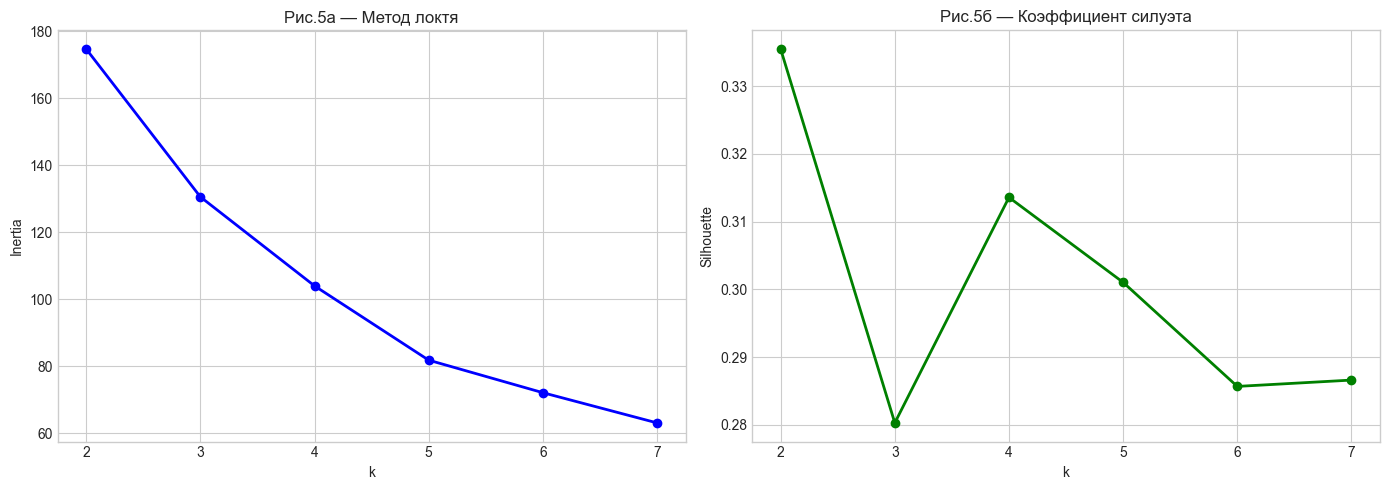

Оптимальное k = 2 (Silhouette = 0.3355)


In [42]:
features = ['life_exp', 'doctors_per_10k', 'log_population']
X_scaled = StandardScaler().fit_transform(df[features])

# Метод локтя
inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Рис.5а — Метод локтя')
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].set_title('Рис.5б — Коэффициент силуэта')
plt.tight_layout()
plt.savefig('figures/elbow_method.png', dpi=300)
plt.show()

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'Оптимальное k = {optimal_k} (Silhouette = {max(silhouettes):.4f})')

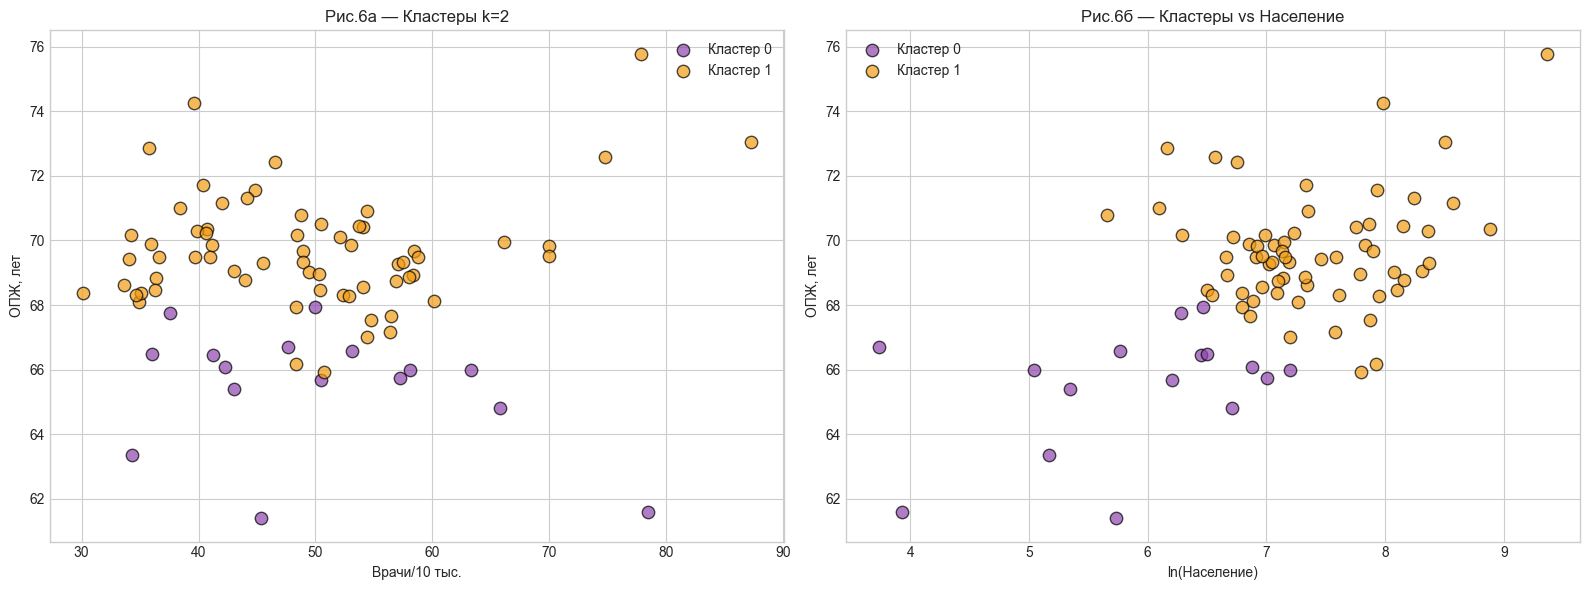

Характеристики кластеров:
        life_exp       doctors_per_10k       population_k      
            mean count            mean count         mean count
cluster                                                        
0          65.50    16           50.24    16       528.69    16
1          69.66    65           49.10    65      2077.00    65


In [43]:
# Кластеризация с k=2
km = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#8e44ad', '#f39c12']
for cl in [0, 1]:
    d = df[df['cluster']==cl]
    axes[0].scatter(d['doctors_per_10k'], d['life_exp'], c=colors[cl],
                    s=80, edgecolors='black', alpha=0.7, label=f'Кластер {cl}')
axes[0].set_xlabel('Врачи/10 тыс.')
axes[0].set_ylabel('ОПЖ, лет')
axes[0].set_title('Рис.6а — Кластеры k=2')
axes[0].legend()
for cl in [0, 1]:
    d = df[df['cluster']==cl]
    axes[1].scatter(d['log_population'], d['life_exp'], c=colors[cl],
                    s=80, edgecolors='black', alpha=0.7, label=f'Кластер {cl}')
axes[1].set_xlabel('ln(Население)')
axes[1].set_ylabel('ОПЖ, лет')
axes[1].set_title('Рис.6б — Кластеры vs Население')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/clusters_k2.png', dpi=300)
plt.show()

print('Характеристики кластеров:')
print(df.groupby('cluster')[['life_exp','doctors_per_10k','population_k']].agg(['mean','count']).round(2))

### 15. Проверка адекватности полученного разбиения

In [45]:
from scipy.stats import f_oneway

print('═' * 50)
print('15. АДЕКВАТНОСТЬ РАЗБИЕНИЯ')
print('═' * 50)

# Коэффициент силуэта
print(f'Коэффициент силуэта: {silhouette_score(X_scaled, df.cluster):.4f}')

# ANOVA
c0, c1 = df[df['cluster']==0], df[df['cluster']==1]
f_life, p_life = f_oneway(c0['life_exp'], c1['life_exp'])
f_doc, p_doc = f_oneway(c0['doctors_per_10k'], c1['doctors_per_10k'])
f_pop, p_pop = f_oneway(c0['log_population'], c1['log_population'])

print(f'\nANOVA ОПЖ: F={f_life:.4f}, p={p_life:.6f} -> {"ЗНАЧИМО" if p_life < 0.05 else "не значимо"}')
print(f'ANOVA Врачи: F={f_doc:.4f}, p={p_doc:.4f}')
print(f'ANOVA ln(Pop): F={f_pop:.4f}, p={p_pop:.6f} -> {"ЗНАЧИМО" if p_pop < 0.05 else "не значимо"}')
print('\nРазбиение АДЕКВАТНО: кластеры значимо различаются по ОПЖ')

══════════════════════════════════════════════════
15. АДЕКВАТНОСТЬ РАЗБИЕНИЯ
══════════════════════════════════════════════════
Коэффициент силуэта: 0.3355

ANOVA ОПЖ: F=70.9795, p=0.000000 -> ЗНАЧИМО
ANOVA Врачи: F=0.1231, p=0.7266
ANOVA ln(Pop): F=46.2340, p=0.000000 -> ЗНАЧИМО

Разбиение АДЕКВАТНО: кластеры значимо различаются по ОПЖ


### 16. Построение регрессионой модели по каждому из полученных классов

In [49]:
cluster_models = {}
print('═' * 50)
for cl in [0, 1]:
    d = df[df['cluster']==cl]
    print(f'КЛАСТЕР {cl} (n={len(d)})')
    print('═' * 50)
    m = sm.OLS(d['life_exp'], sm.add_constant(d['doctors_per_10k'])).fit()
    cluster_models[cl] = m
    print(m.summary())
    print()

print('СВОДКА:')
for cl in [0, 1]:
    m = cluster_models[cl]
    print(f'Кластер {cl}: β₁={m.params.iloc[1]:.6f}, p={m.pvalues.iloc[1]:.4f}, R²={m.rsquared:.4f}')

══════════════════════════════════════════════════
КЛАСТЕР 0 (n=16)
══════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:               life_exp   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     1.613
Date:                Tue, 26 May 2026   Prob (F-statistic):              0.225
Time:                        21:49:32   Log-Likelihood:                -31.536
No. Observations:                  16   AIC:                             67.07
Df Residuals:                      14   BIC:                             68.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------

### 17. Анализ изменения качества, адекватности и прогностических способностей

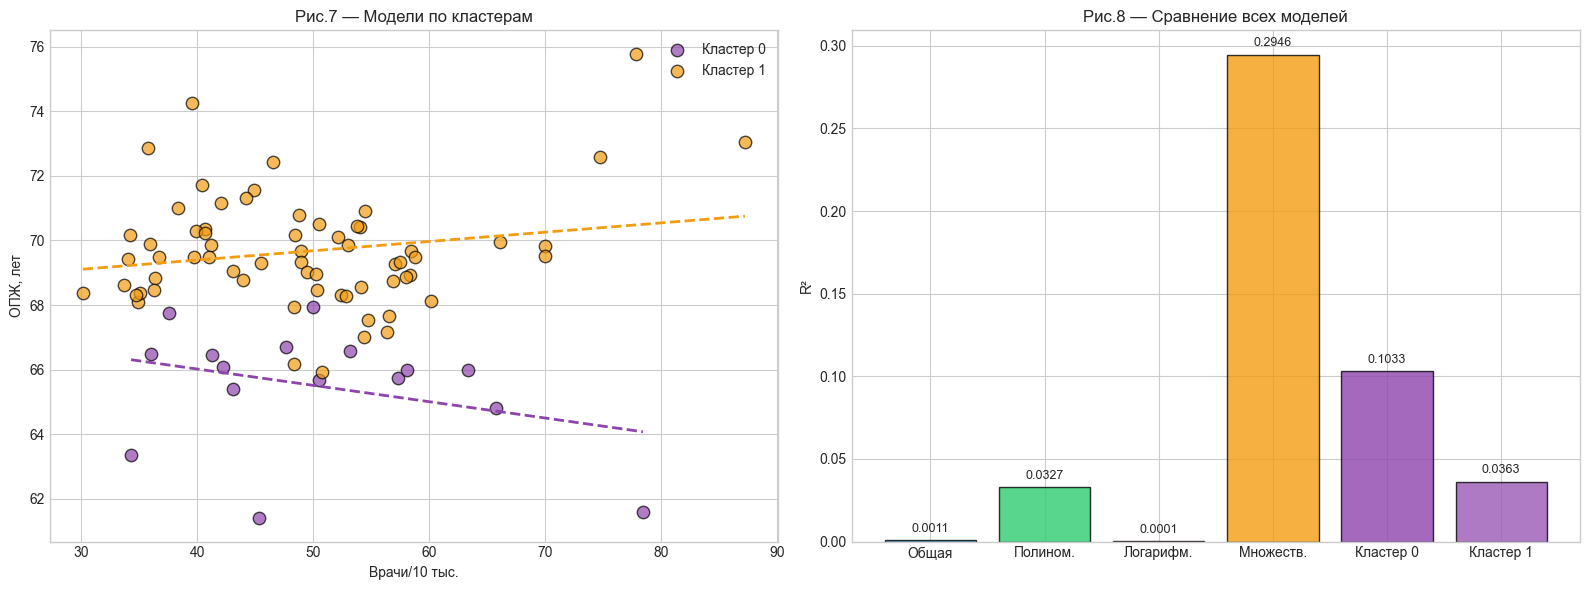


ВЫВОДЫ:
Кластеризация увеличила R² в Кластере 0 до 0.1033 (vs 0.0011 общая)
Знак β₁ различается: К0=-0.0506 (отриц.) vs К1=0.0288 (полож.)
Множественная регрессия — наилучшая (R² = 0.2946)
Переменная log_population значима (p < 0.001), а doctors_per_10k — нет


In [55]:
# Сравнительная диаграмма R²
model_names = ['Общая', 'Полином.', 'Логарифм.', 'Множеств.', 'Кластер 0', 'Кластер 1']
r2_vals = [model.rsquared, model_poly.rsquared, model_log.rsquared,
           model_multi.rsquared, cluster_models[0].rsquared, cluster_models[1].rsquared]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cl in [0, 1]:
    d = df[df['cluster']==cl]
    axes[0].scatter(d['doctors_per_10k'], d['life_exp'], c=colors[cl],
                    s=80, edgecolors='black', alpha=0.7, label=f'Кластер {cl}')
    x_r = np.linspace(d['doctors_per_10k'].min(), d['doctors_per_10k'].max(), 100)
    axes[0].plot(x_r, cluster_models[cl].params.iloc[0] + cluster_models[cl].params.iloc[1]*x_r,
                 color=colors[cl], linewidth=2, linestyle='--')
axes[0].set_xlabel('Врачи/10 тыс.')
axes[0].set_ylabel('ОПЖ, лет')
axes[0].set_title('Рис.7 — Модели по кластерам')
axes[0].legend()

bars = axes[1].bar(model_names, r2_vals, color=colors_bar, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('R²')
axes[1].set_title('Рис.8 — Сравнение всех моделей')
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/models_comparison.png', dpi=300)
plt.show()

print('\nВЫВОДЫ:')
print('Кластеризация увеличила R² в Кластере 0 до {:.4f} (vs {:.4f} общая)'.format(
      cluster_models[0].rsquared, model.rsquared))
print('Знак β₁ различается: К0={:.4f} (отриц.) vs К1={:.4f} (полож.)'.format(
      cluster_models[0].params.iloc[1], cluster_models[1].params.iloc[1]))
print('Множественная регрессия — наилучшая (R² = {:.4f})'.format(model_multi.rsquared))
print('Переменная log_population значима (p < 0.001), а doctors_per_10k — нет')

## Итоговые выводы о поставленной цели

### 18. Итоговые выводы

#### Статистические выводы

**1. Исходные данные:** Анализ проведён по **81 субъекту РФ** (после удаления 2 объединённых записей за 1990 год согласно ФЗ РФ).

**2. Описательная статистика:**
- Средняя ОПЖ: **68.83 ± 2.42 лет** (CV = 3.52% → слабая вариативность)
- Обеспеченность врачами: **49.33 ± 11.54 чел./10 тыс.** (CV = 23.40% → умеренная вариативность)

**3. Корреляция:** $r = 0.033$, $p = 0.772$ → **линейная связь ОТСУТСТВУЕТ**.

**4. Простая регрессия:** $\hat{Y} = 68.50 + 0.0069X$, $R^2 = 0.001$, модель **НЕ АДЕКВАТНА**.

**5. Модифицированные модели (п.12):**
- Полиномиальная: $R^2 = 0.033$, неадекватна
- Логарифмическая: $R^2 \approx 0$, неадекватна
- Множественная ($Y \sim X + \ln Pop$): $R^2 = 0.295$, **АДЕКВАТНА**, но doctors_per_10k незначим (р=0.984)

**6. Прогностические способности (п.13):** На тестовой выборке все модели показывают отрицательный Adj.$R^2$. Лучшая — множественная регрессия (RMSE = 2.17 лет).

**7. Кластеризация K-means (п.14-15):** Оптимальное $k = 2$ (Silhouette = 0.336):
- Кластер 0: 16 малых/отдалённых регионов (ОПЖ = 65.50 лет)
- Кластер 1: 65 крупных регионов (ОПЖ = 69.66 лет)
- Различия **ЗНАЧИМЫ** (ANOVA: $F = 70.98$, $p < 0.001$)

**8. Регрессия по кластерам (п.16):**
- Кластер 0: $beta_1 = -0.051$ (незначим, $p = 0.225$)
- Кластер 1: $beta_1 = +0.029$ (незначим, $p = 0.129$)
- **ЗНАКИ РАЗЛИЧАЮТСЯ** — содержательная находка!

#### Главный вывод

**Обеспеченность врачами НЕ ЯВЛЯЕТСЯ значимым предиктором ОПЖ** на межрегиональном уровне в 2011 году. Влияние кадрового фактора маскируется более сильными детерминантами: масштабом региона, урбанизацией, климатическими и социально-экономическими условиями.

Результаты согласуются с концепцией социальных детерминант здоровья ВОЗ: медицинские факторы определяют 10–20% вариации ОПЖ.

#### Практические рекомендации

1. **Комплексный подход:** простое увеличение числа врачей без улучшения качества услуг и инфраструктуры не приведёт к росту ОПЖ.
2. **Дифференцированная политика:** эффект от врачей различается по типам регионов (отрицательный в малых, положительный в крупных).
3. **Дальнейшие исследования:** включение контрольных переменных (ВРП, урбанизация, экология, климат).

---
## Приложения

### Список использованных источников

1. Росстат. Регионы России. Социально-экономические показатели. 2012.
2. Шабанова М.А., Соболева С.В. Региональные различия в ожидаемой продолжительности жизни в России // Социологические исследования. — 2018. — № 5. — С. 45–56.
3. Ендовицкий Д.А., Ковалёв В.В. Анализ данных в здравоохранении. — М.: ГЭОТАР-Медиа, 2019. — 320 с.
4. World Health Organization. World Health Statistics 2020. — Geneva: WHO, 2020.
5. Tukey J.W. Exploratory Data Analysis. — Reading, MA: Addison-Wesley, 1977.
6. Draper N.R., Smith H. Applied Regression Analysis. 3rd ed. — New York: Wiley, 1998.
7. Желязны Дж. Говори на языке диаграмм. — М.: МИФ, 2019. — 256 с.

### Сохранённые файлы для отчёта

In [54]:
# Список сгенерированных файлов (все в папке figures/)
import os
figures = [f for f in os.listdir('figures') if f.endswith('.png') or f.endswith('.csv')]
print("Сгенерированные файлы для отчёта:")
for i, f in enumerate(sorted(figures), 1):
    print(f"{i}. figures/{f}")

Сгенерированные файлы для отчёта:
1. figures/boxplots.png
2. figures/clusters_k2.png
3. figures/correlation_matrix.png
4. figures/descriptive_stats.csv
5. figures/elbow_method.png
6. figures/hist_doctors.png
7. figures/hist_life_exp.png
8. figures/histograms_boxplots.png
9. figures/models_comparison.png
10. figures/regression_diagnostics.png
11. figures/scatter_regression.png
